<a href="https://colab.research.google.com/github/Adittopiwala2/Adit-/blob/master/Notebooks/CIFAR10_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
#loading data set
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
x_train = train_images/255.0
x_test = test_images/255.0
y_train = train_labels
y_test = test_labels

class_name = ['airplane', 'automobile', 'bird', 'cat', 'dear', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape: ",x_train.shape)
print("Training labels shape: ",y_train.shape)
print("Testing data shape: ",x_test.shape)
print("Testing labels shape: ",y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 304s 2us/step
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Testing data shape:  (10000, 32, 32, 3)
Testing labels shape:  (10000, 1)


In [4]:
def create_CNN_model1():
  model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Dropout(0.25), # Added dropout after the last convolutional block
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25), # Added dropout after the first dense layer
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

  model.summary()
  return model

In [5]:
def create_CNN_model2():
  model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25), # Added dropout after the first dense layer
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

  model.summary()
  return model

In [6]:
def create_CNN_model3():
  model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

  model.summary()
  return model

In [7]:
def create_CNN_model4():
  model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

  model.summary()
  return model

In [8]:
def create_CNN_model5():
  model = tf.keras.models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation=None) # Changed activation to None (linear) for logits
])

  model.summary()
  return model

In [9]:
model_1 = create_CNN_model1()
model_2 = create_CNN_model2()
model_3 = create_CNN_model3()
model_4 = create_CNN_model4()
model_5 = create_CNN_model5()

# Compile and train all models
all_models = [model_1, model_2, model_3, model_4, model_5]
for idx, model in enumerate(all_models):
  print(f"\nTraining Model {idx+1}")
  model.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])
  model.history_object = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
  # Store evaluation results in a new attribute for clarity
  print(f"\nEvaluating Model {idx+1} on test data")
  loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
  model.test_loss = loss
  model.test_accuracy = accuracy
  print(f"Model {idx+1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Example of how to access the training history and test results for each model
for i, model in enumerate(all_models):
  print(f"\n--- Model {i+1} Training History ---")
  print("Accuracy per epoch:", model.history_object.history['accuracy'])
  print("Validation Accuracy per epoch:", model.history_object.history['val_accuracy'])
  print("Loss per epoch:", model.history_object.history['loss'])
  print("Validation Loss per epoch:", model.history_object.history['val_loss'])
  print(f"Model {i+1} Final Test Accuracy: {model.test_accuracy:.4f}")
  print(f"Model {i+1} Final Test Loss: {model.test_loss:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,426 (1.39 MB)

 Trainable params: 364,426 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,946 (656.04 KB)

 Trainable params: 167,754 (655.29 KB)

 Non-trainable params: 192 (768.00 B)


Training Model 1
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.3716 - loss: 1.6926 - val_accuracy: 0.4919 - val_loss: 1.3682
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.5281 - loss: 1.3076 - val_accuracy: 0.5909 - val_loss: 1.1515
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.5899 - loss: 1.1496 - val_accuracy: 0.6304 - val_loss: 1.0568
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6344 - loss: 1.0365 - val_accuracy: 0.6480 - val_loss: 1.0043
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.6658 - loss: 0.9478 - val_accuracy: 0.6755 - val_loss: 0.9114
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.6875 - loss: 0.8824 - val_accuracy: 0.6921 - val_loss: 0.8644
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 95ms/step - accuracy: 0.7099 - loss: 0.8280 - val_accuracy: 0.7034 - val_loss: 0.8506
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.7

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Ensemble Accuracy: 75.04%


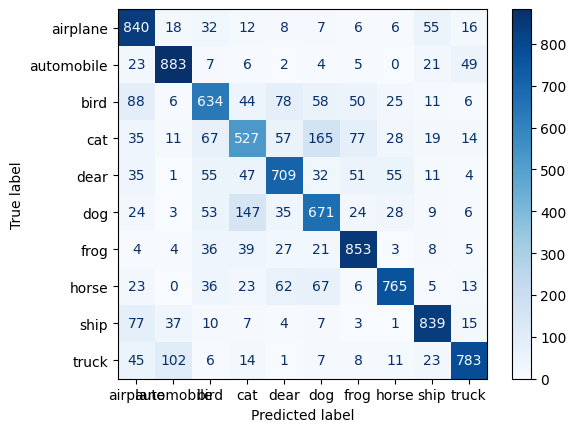

In [10]:
prediction_1 = model_1.predict(x_test)
prediction_2 = model_2.predict(x_test)
prediction_3 = model_3.predict(x_test)
prediction_4 = model_4.predict(x_test)
prediction_5 = model_5.predict(x_test)

ensemble_predictions = (prediction_1 + prediction_2 + prediction_3 + prediction_4 + prediction_5) / 5.0

y_pred_ensemble = np.argmax(ensemble_predictions, axis=1)
y_true = np.squeeze(y_test)

accuracy_ensemble = np.mean(y_pred_ensemble == y_true)
print(f"Ensemble Accuracy: {accuracy_ensemble * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
disp.plot(cmap=plt.cm.Blues)
plt.show()